In [ ]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [43]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [44]:
pip install scipy

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [45]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [67]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 9.9 MB 7.3 MB/s eta 0:00:01
     |████████████████████████████████| 449 kB 30.4 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [75]:
pip install Bokeh

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.0 MB 671 kB/s eta 0:00:01
     |████████████████████████████████| 174 kB 3.1 MB/s eta 0:00:01
     |████████████████████████████████| 94 kB 2.0 MB/s eta 0:00:011
     |████████████████████████████████| 134 kB 5.5 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [76]:
pip install plotnine

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.3 MB 1.9 MB/s eta 0:00:01
     |████████████████████████████████| 127 kB 4.4 MB/s eta 0:00:01
     |████████████████████████████████| 10.0 MB 4.2 MB/s eta 0:00:01    |███████████████▏                | 4.8 MB 3.3 MB/s eta 0:00:02
     |████████████████████████████████| 233 kB 4.3 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


Loading data...


/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/3812562463.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  encounters["Date"] = pd.to_datetime(encounters["Date"])



=== CONTINUITY METRICS ===
Avg Gap: 23.3
Long Gap %: 11.51
Avg Visits: 1.82


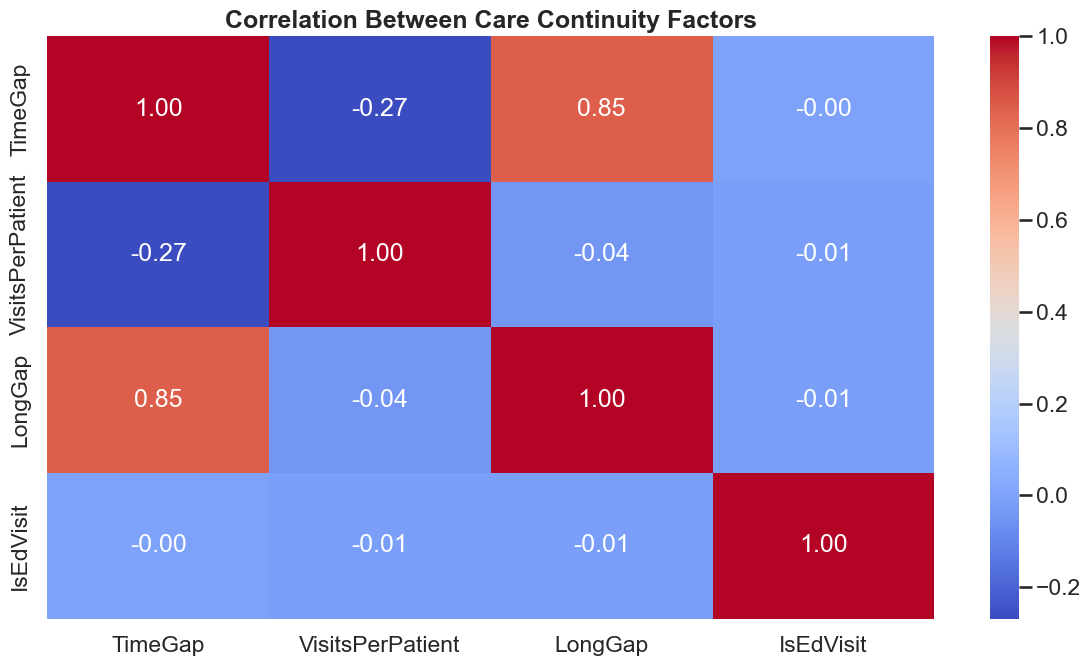

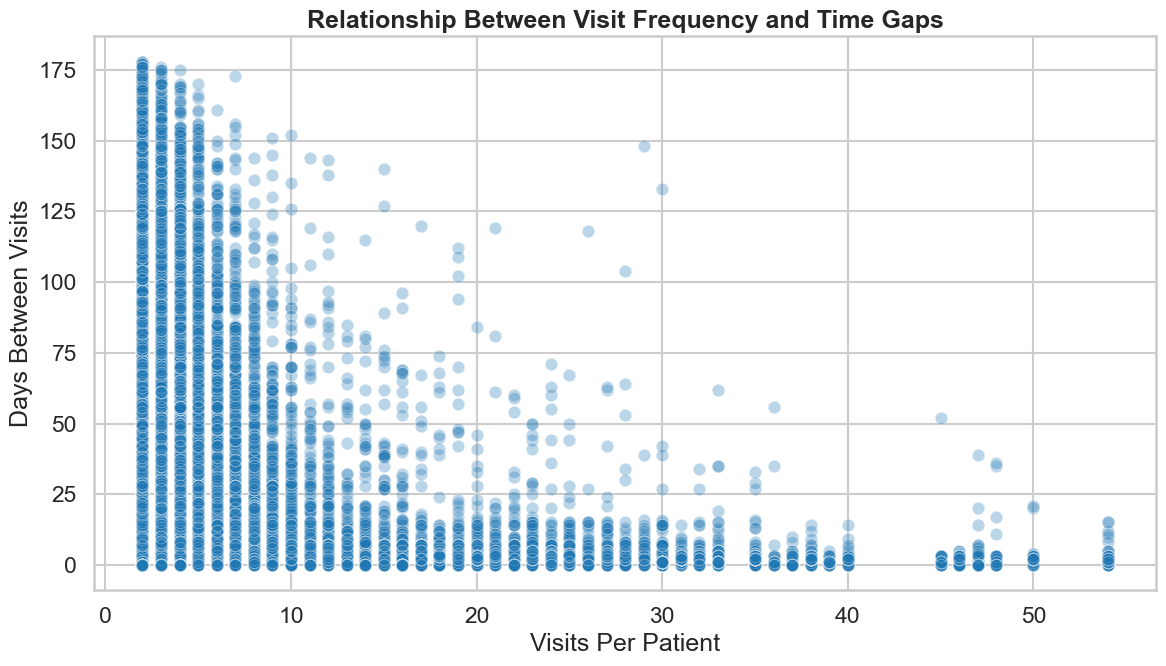

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/3812562463.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


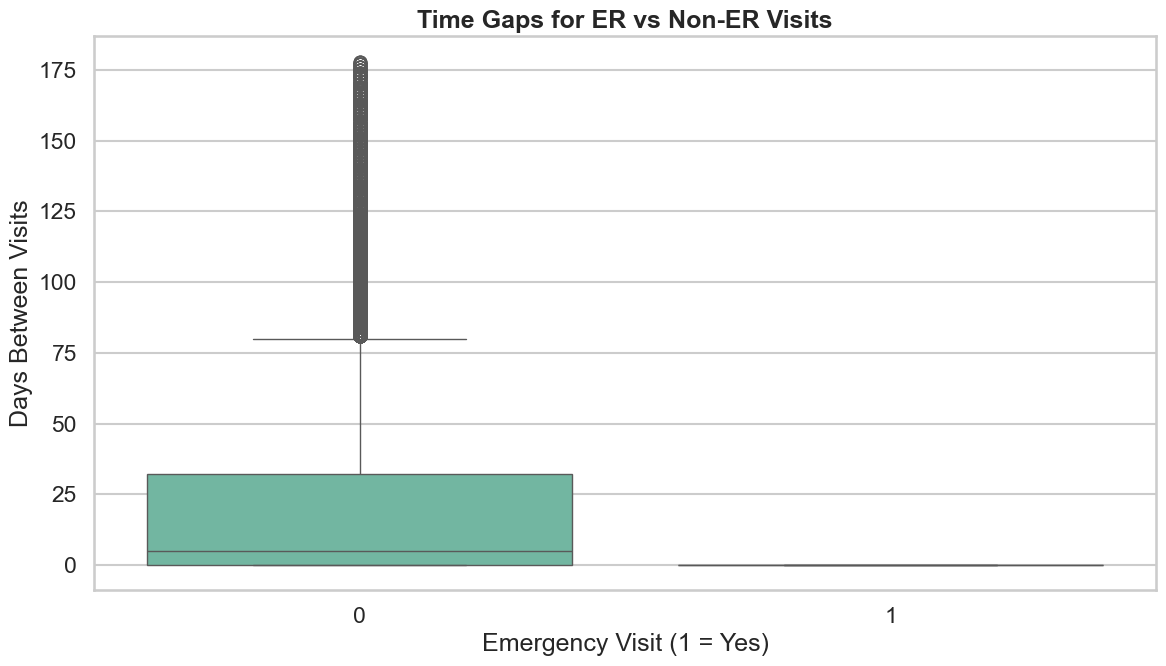

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/3812562463.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


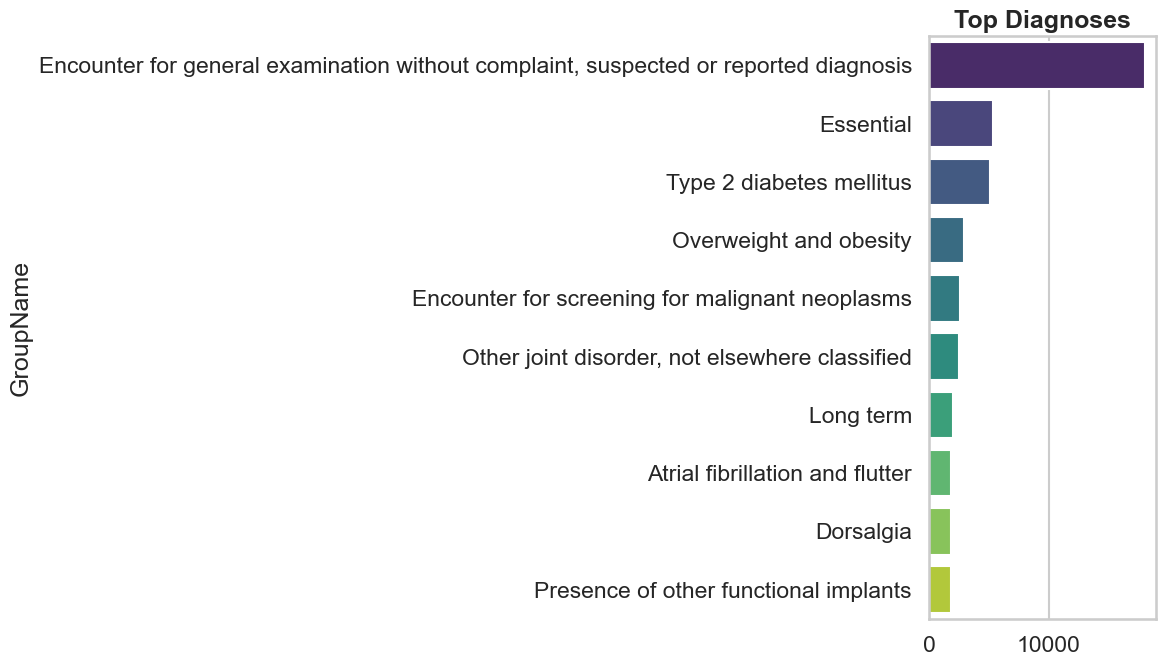


DONE 🔥


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (12, 7)

print("Loading data...")

encounters = pd.read_csv("/Users/sampanackal/Documents/DATAFEST 26/encounters.csv", nrows=100000)
patients = pd.read_csv("/Users/sampanackal/Documents/DATAFEST 26/patients.csv")
diagnosis = pd.read_csv("/Users/sampanackal/Documents/DATAFEST 26/diagnosis.csv")
census = pd.read_csv("/Users/sampanackal/Documents/DATAFEST 26/tigercensuscodes.csv")

def clean(df):
    df.columns = df.columns.str.strip()
    return df

encounters = clean(encounters)
patients = clean(patients)
diagnosis = clean(diagnosis)
census = clean(census)


encounters = encounters[[
    "PatientDurableKey",
    "Date",
    "PrimaryDiagnosisKey",
    "VisitType",
    "IsEdVisit"
]]

patients = patients[[
    "DurableKey",
    "CensusBlockGroupFipsCode"
]]

diagnosis = diagnosis[[
    "DiagnosisKey",
    "GroupName"
]]

census = census[[
    "GEOID",
    "PopulationValue",
    "CENTLAT",
    "CENTLON"
]]

encounters["Date"] = pd.to_datetime(encounters["Date"])

df = encounters.merge(
    patients,
    left_on="PatientDurableKey",
    right_on="DurableKey",
    how="left"
)

df = df.merge(
    diagnosis,
    left_on="PrimaryDiagnosisKey",
    right_on="DiagnosisKey",
    how="left"
)

# FIX TYPES
df["CensusBlockGroupFipsCode"] = df["CensusBlockGroupFipsCode"].astype(str)
census["GEOID"] = census["GEOID"].astype(str)

df = df.merge(
    census,
    left_on="CensusBlockGroupFipsCode",
    right_on="GEOID",
    how="left"
)

df = df.sort_values(by=["PatientDurableKey", "Date"])

df["PrevDate"] = df.groupby("PatientDurableKey")["Date"].shift(1)
df["TimeGap"] = (df["Date"] - df["PrevDate"]).dt.days
df["LongGap"] = df["TimeGap"] > 30

visits_per_patient = df.groupby("PatientDurableKey").size()
df["VisitsPerPatient"] = df["PatientDurableKey"].map(visits_per_patient)

print("\n=== CONTINUITY METRICS ===")
print("Avg Gap:", round(df["TimeGap"].mean(), 2))
print("Long Gap %:", round(df["LongGap"].mean()*100, 2))
print("Avg Visits:", round(visits_per_patient.mean(), 2))

corr_df = df[["TimeGap", "VisitsPerPatient", "LongGap", "IsEdVisit"]].copy()
corr_df["LongGap"] = corr_df["LongGap"].astype(int)

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Care Continuity Factors", weight='bold')
plt.tight_layout()
plt.show()

sns.scatterplot(
    x="VisitsPerPatient",
    y="TimeGap",
    data=df,
    alpha=0.3
)
plt.title("Relationship Between Visit Frequency and Time Gaps", weight='bold')
plt.xlabel("Visits Per Patient")
plt.ylabel("Days Between Visits")
plt.tight_layout()
plt.show()

sns.boxplot(
    x="IsEdVisit",
    y="TimeGap",
    data=df,
    palette="Set2"
)
plt.title("Time Gaps for ER vs Non-ER Visits", weight='bold')
plt.xlabel("Emergency Visit (1 = Yes)")
plt.ylabel("Days Between Visits")
plt.tight_layout()
plt.show()

top_conditions = df["GroupName"].value_counts().head(10)

sns.barplot(
    x=top_conditions.values,
    y=top_conditions.index,
    palette="viridis"
)
plt.title("Top Diagnoses", weight='bold')
plt.tight_layout()
plt.show()

print("\nDONE 🔥")

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/509472875.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


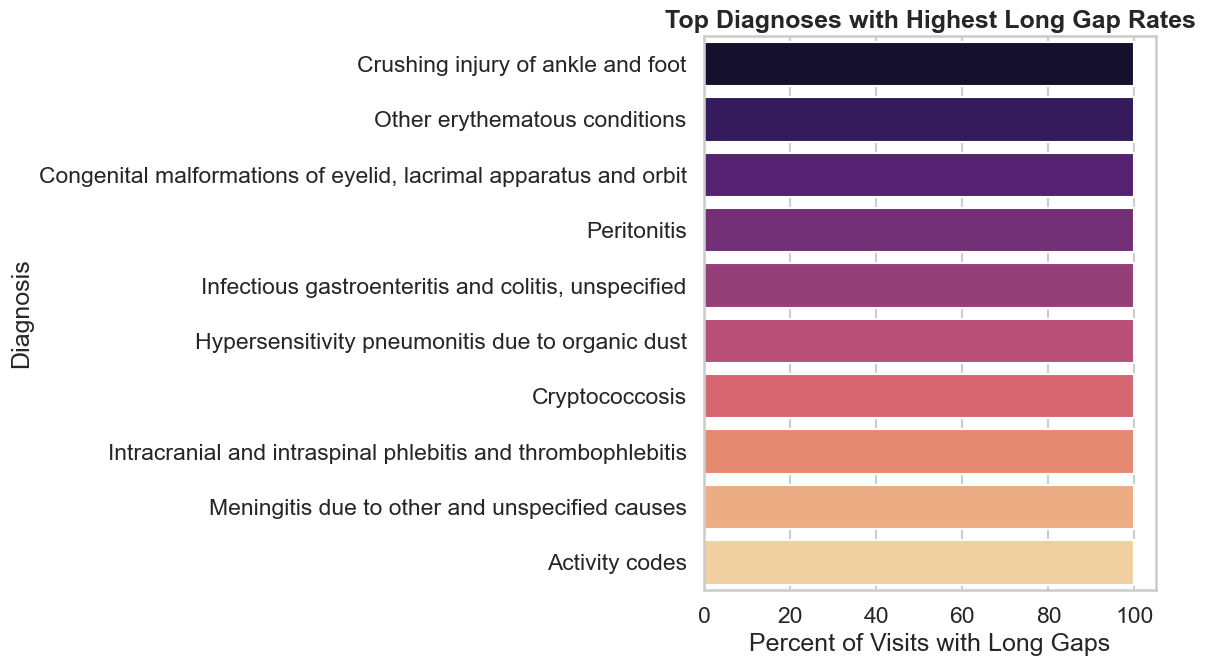

In [47]:
gap_by_condition = df.groupby("GroupName")["LongGap"].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=gap_by_condition.values * 100,
    y=gap_by_condition.index,
    palette="magma"
)

plt.title("Top Diagnoses with Highest Long Gap Rates", weight='bold')
plt.xlabel("Percent of Visits with Long Gaps")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.show()

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/1992186615.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


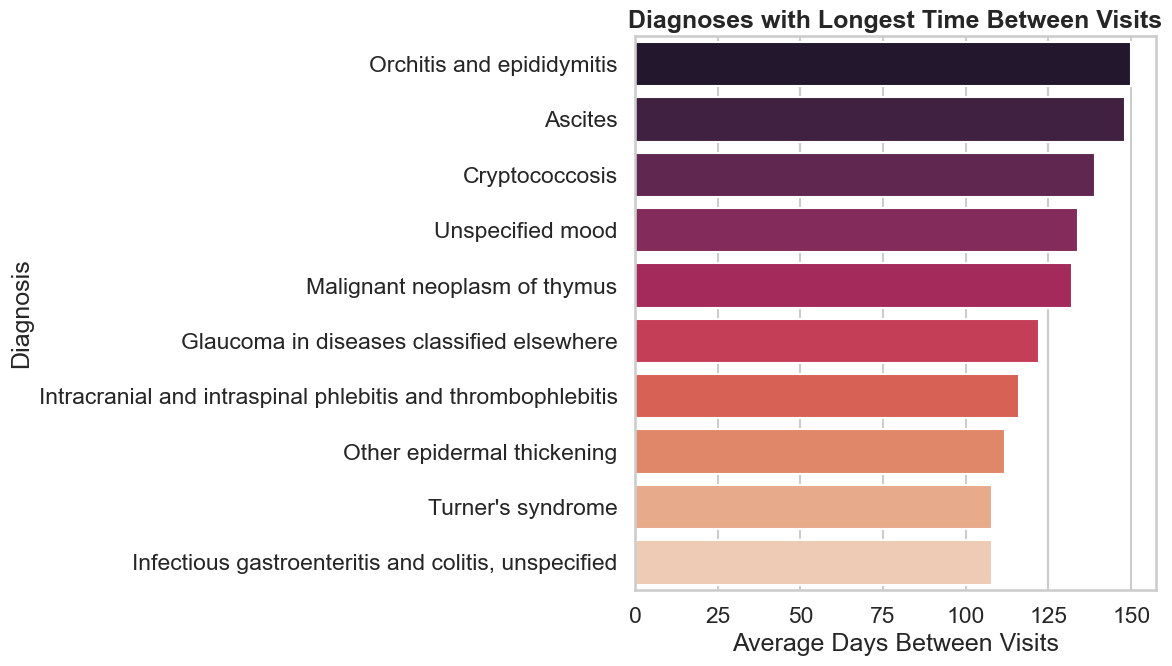

In [48]:
avg_gap_by_condition = df.groupby("GroupName")["TimeGap"].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=avg_gap_by_condition.values,
    y=avg_gap_by_condition.index,
    palette="rocket"
)

plt.title("Diagnoses with Longest Time Between Visits", weight='bold')
plt.xlabel("Average Days Between Visits")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.show()

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/4035760183.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


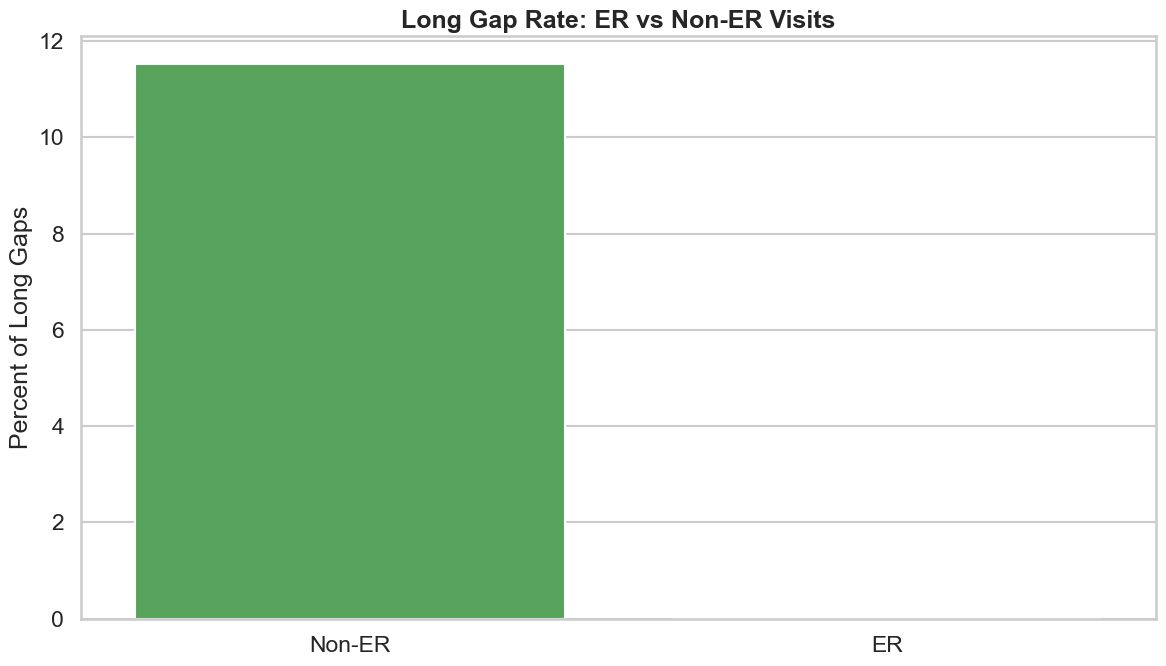

In [49]:
er_gap = df.groupby("IsEdVisit")["LongGap"].mean()

sns.barplot(
    x=["Non-ER", "ER"],
    y=er_gap.values * 100,
    palette=["#4CAF50", "#E74C3C"]
)

plt.title("Long Gap Rate: ER vs Non-ER Visits", weight='bold')
plt.ylabel("Percent of Long Gaps")
plt.tight_layout()
plt.show()

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/625162695.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


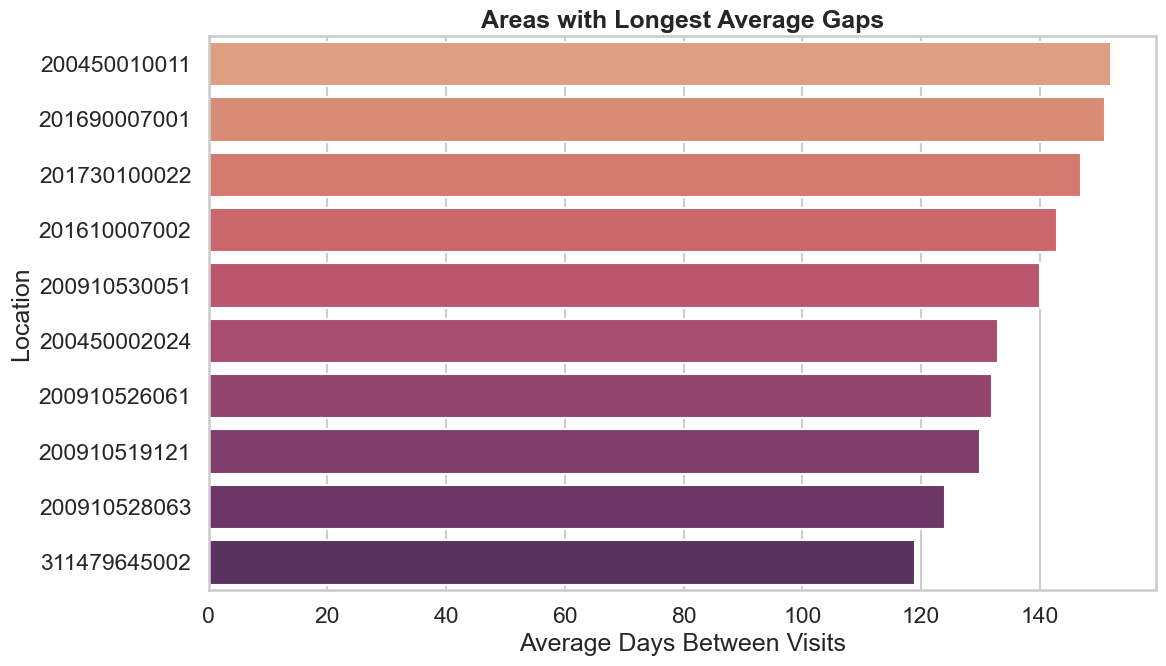

In [50]:
location_gap = df.groupby("CensusBlockGroupFipsCode")["TimeGap"].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=location_gap.values,
    y=location_gap.index,
    palette="flare"
)

plt.title("Areas with Longest Average Gaps", weight='bold')
plt.xlabel("Average Days Between Visits")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/946798466.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


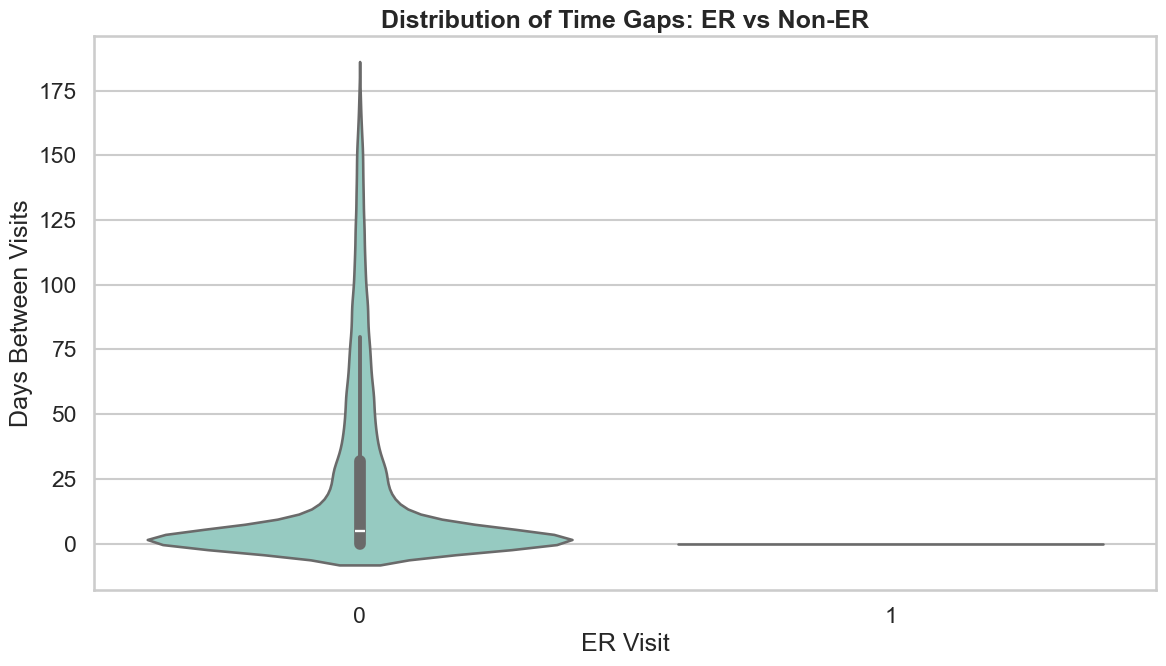

In [51]:
sns.violinplot(
    x="IsEdVisit",
    y="TimeGap",
    data=df,
    palette="Set3"
)

plt.title("Distribution of Time Gaps: ER vs Non-ER", weight='bold')
plt.xlabel("ER Visit")
plt.ylabel("Days Between Visits")
plt.tight_layout()
plt.show()

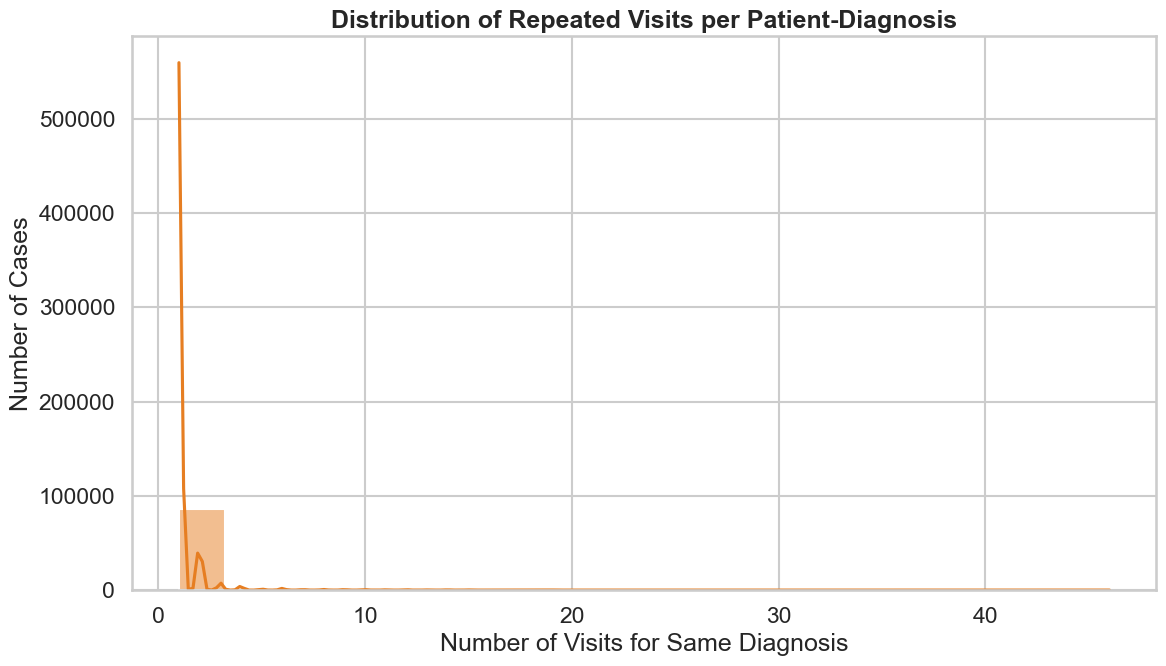

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/3612508899.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


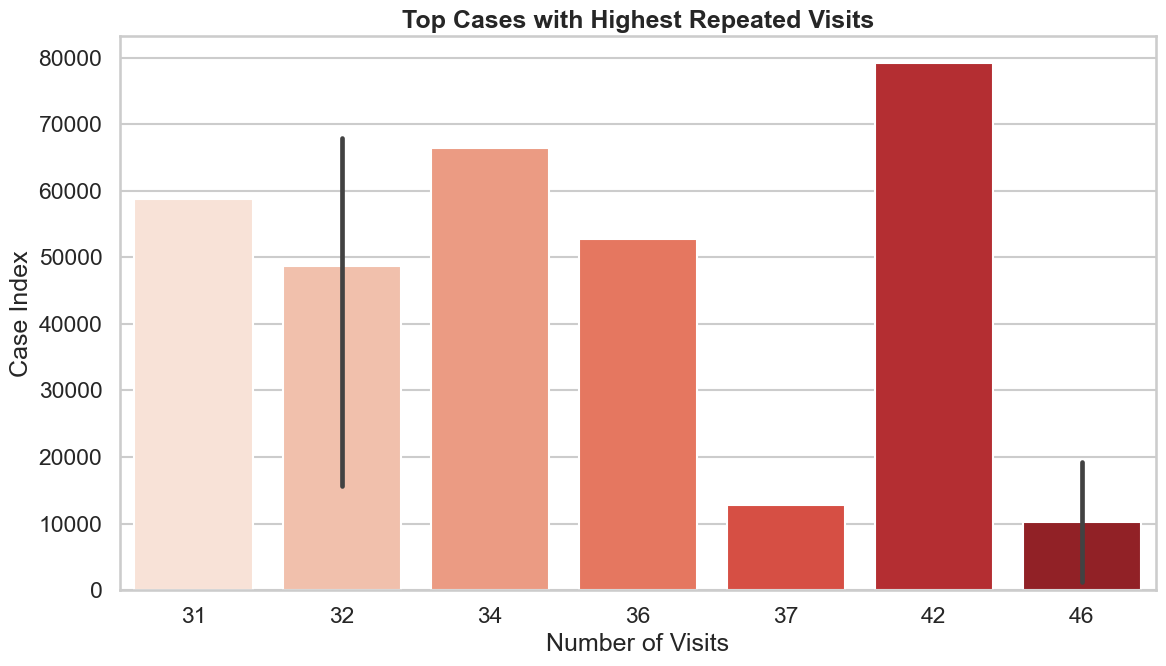

In [52]:
repeat_tests = df.groupby(
    ["PatientDurableKey", "PrimaryDiagnosisKey"]
).size().reset_index(name="VisitCount")

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    repeat_tests["VisitCount"],
    bins=20,
    kde=True,
    color="#E67E22"
)

plt.title("Distribution of Repeated Visits per Patient-Diagnosis", weight='bold')
plt.xlabel("Number of Visits for Same Diagnosis")
plt.ylabel("Number of Cases")

plt.tight_layout()
plt.show()

top_repeats = repeat_tests.sort_values(by="VisitCount", ascending=False).head(10)

sns.barplot(
    x=top_repeats["VisitCount"],
    y=top_repeats.index,
    palette="Reds"
)

plt.title("Top Cases with Highest Repeated Visits", weight='bold')
plt.xlabel("Number of Visits")
plt.ylabel("Case Index")

plt.tight_layout()
plt.show()

In [53]:
from scipy.stats import pearsonr

corr_data = df[["VisitsPerPatient", "TimeGap"]].dropna()

corr, p_value = pearsonr(corr_data["VisitsPerPatient"], corr_data["TimeGap"])

print("\n=== CORRELATION TEST ===")
print("Correlation:", round(corr, 3))
print("p-value:", p_value)


=== CORRELATION TEST ===
Correlation: -0.269
p-value: 0.0


In [54]:
from scipy.stats import ttest_ind

df_valid = df[df["TimeGap"].notna()]

visits_per_patient = df_valid.groupby("PatientDurableKey").size()
df_valid["VisitsPerPatient"] = df_valid["PatientDurableKey"].map(visits_per_patient)

median_visits = df_valid["VisitsPerPatient"].median()

df_valid["HighVisits"] = df_valid["VisitsPerPatient"] > median_visits

high = df_valid[df_valid["HighVisits"] == True]["TimeGap"]
low = df_valid[df_valid["HighVisits"] == False]["TimeGap"]

print("High count:", len(high))
print("Low count:", len(low))

t_stat, p_value = ttest_ind(high, low, equal_var=False)

print("\n=== HIGH VS LOW VISIT TEST ===")
print("t-stat:", t_stat)
print("p-value:", p_value)

print("High visit mean gap:", high.mean())
print("Low visit mean gap:", low.mean())

High count: 21659
Low count: 26936

=== HIGH VS LOW VISIT TEST ===
t-stat: -75.75960713156178
p-value: 0.0
High visit mean gap: 11.09418717392308
Low visit mean gap: 33.11716661716662


/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/2158793072.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["VisitsPerPatient"] = df_valid["PatientDurableKey"].map(visits_per_patient)
/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/2158793072.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["HighVisits"] = df_valid["VisitsPerPatient"] > median_visits


In [55]:
from scipy.stats import f_oneway

top_diag = repeat_tests.merge(
    diagnosis,
    left_on="PrimaryDiagnosisKey",
    right_on="DiagnosisKey",
    how="left"
)

top_groups = top_diag["GroupName"].value_counts().head(5).index

groups = [
    top_diag[top_diag["GroupName"] == g]["VisitCount"].dropna()
    for g in top_groups
]

f_stat, p_value = f_oneway(*groups)

print("\n=== ANOVA TEST (REPEATS BY DIAGNOSIS) ===")
print("F-stat:", f_stat)
print("p-value:", p_value)


=== ANOVA TEST (REPEATS BY DIAGNOSIS) ===
F-stat: 7906.178933404733
p-value: 0.0


In [57]:
# Only keep rows with valid TimeGap
df_valid = df[df["TimeGap"].notna()].copy()

# Calculate visits per patient
visits_per_patient = df_valid.groupby("PatientDurableKey").size()

# Add visits count to dataframe
df_valid["VisitsPerPatient"] = df_valid["PatientDurableKey"].map(visits_per_patient)

# Split into high vs low groups
median_visits = df_valid["VisitsPerPatient"].median()

df_valid["HighVisits"] = df_valid["VisitsPerPatient"] > median_visits

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/3984947071.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


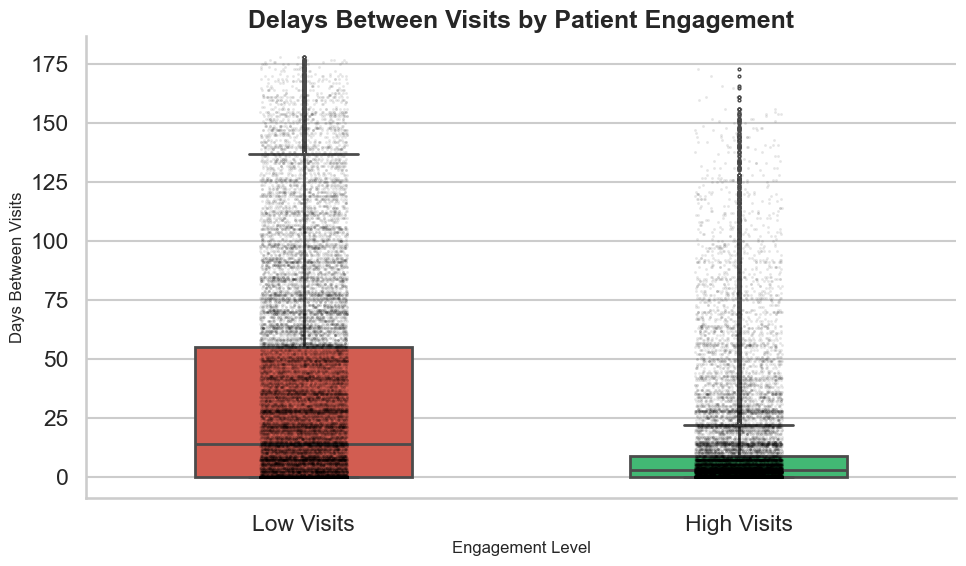

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# Theme
sns.set_style("whitegrid")
sns.set_context("talk")

# Color system (same as before)
LOW = "#E74C3C"   # red
HIGH = "#2ECC71"  # green

# Create figure
plt.figure(figsize=(10, 6))

# Boxplot (clean + styled)
sns.boxplot(
    x="HighVisits",
    y="TimeGap",
    data=df_valid,
    palette=[LOW, HIGH],
    width=0.5,
    linewidth=2,
    fliersize=2
)

# Overlay subtle strip plot for detail (makes it look advanced)
sns.stripplot(
    x="HighVisits",
    y="TimeGap",
    data=df_valid,
    color="black",
    alpha=0.1,
    size=2,
    jitter=True
)

# Labels
plt.title("Delays Between Visits by Patient Engagement", fontsize=18, weight='bold')
plt.xlabel("Engagement Level", fontsize=12)
plt.ylabel("Days Between Visits", fontsize=12)

# Replace True/False labels
plt.xticks([0, 1], ["Low Visits", "High Visits"])

# Remove top/right borders for clean look
sns.despine()

plt.tight_layout()
plt.show()

In [60]:
from scipy.stats import ttest_ind

# Split groups
high = df_valid[df_valid["HighVisits"] == True]["TimeGap"]
low = df_valid[df_valid["HighVisits"] == False]["TimeGap"]

# Run test
t_stat, p_value = ttest_ind(high, low, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_value)

print("High mean:", high.mean())
print("Low mean:", low.mean())

t-stat: -75.75960713156178
p-value: 0.0
High mean: 11.09418717392308
Low mean: 33.11716661716662


In [61]:
group_means = df_valid.groupby("HighVisits")["TimeGap"].mean()
print(group_means)

HighVisits
False    33.117167
True     11.094187
Name: TimeGap, dtype: float64


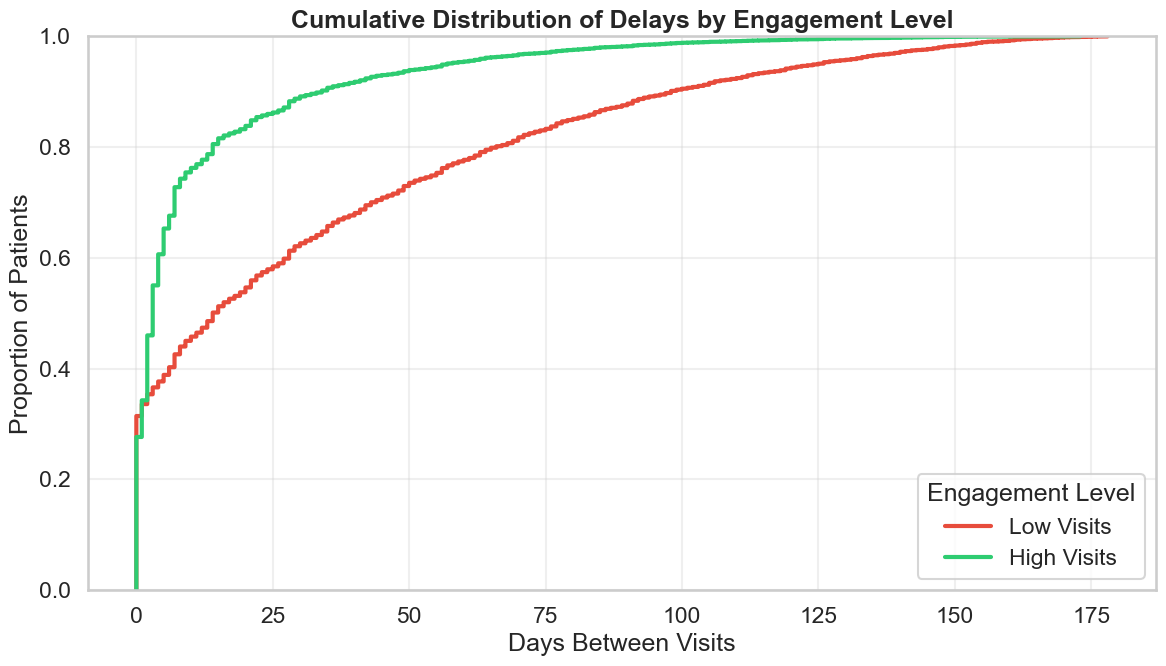

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Split groups
high = df_valid[df_valid["HighVisits"] == True]["TimeGap"]
low = df_valid[df_valid["HighVisits"] == False]["TimeGap"]

# Plot cumulative distributions
sns.ecdfplot(low, label="Low Visits", color="#E74C3C", linewidth=3)
sns.ecdfplot(high, label="High Visits", color="#2ECC71", linewidth=3)

# Styling
plt.title("Cumulative Distribution of Delays by Engagement Level", fontsize=18, weight='bold')
plt.xlabel("Days Between Visits")
plt.ylabel("Proportion of Patients")

plt.legend(title="Engagement Level")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [66]:
from scipy.stats import ttest_ind

high = df_valid[df_valid["HighVisits"] == True]["TimeGap"]
low = df_valid[df_valid["HighVisits"] == False]["TimeGap"]

t_stat, p_value = ttest_ind(high, low, equal_var=False)

print("=== 1B STAT TEST (CDF SUPPORT) ===")
print("t-stat:", t_stat)
print("p-value:", p_value)

print("High mean:", high.mean())
print("Low mean:", low.mean())

=== 1B STAT TEST (CDF SUPPORT) ===
t-stat: -75.75960713156178
p-value: 0.0
High mean: 11.09418717392308
Low mean: 33.11716661716662


In [68]:
import plotly.express as px
import pandas as pd

# Prepare data
high = df_valid[df_valid["HighVisits"] == True]["TimeGap"]
low = df_valid[df_valid["HighVisits"] == False]["TimeGap"]

# Create combined dataframe
cdf_data = pd.DataFrame({
    "TimeGap": pd.concat([low, high]),
    "Group": ["Low Visits"] * len(low) + ["High Visits"] * len(high)
})

# Create ECDF plot
fig = px.ecdf(
    cdf_data,
    x="TimeGap",
    color="Group",
    color_discrete_map={
        "Low Visits": "#E74C3C",
        "High Visits": "#2ECC71"
    },
    title="Interactive View: How Quickly Patients Receive Follow-Up Care"
)

# Styling
fig.update_layout(
    xaxis_title="Days Between Visits",
    yaxis_title="Proportion of Patients",
    legend_title="Engagement Level",
    template="simple_white",
    font=dict(size=16)
)

# Make lines thicker
fig.update_traces(line=dict(width=4))

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [69]:
import plotly.express as px
import pandas as pd

# -----------------------------
# 1. PREP DATA
# -----------------------------
high = df_valid[df_valid["HighVisits"] == True]["TimeGap"]
low = df_valid[df_valid["HighVisits"] == False]["TimeGap"]

# Combine into one DataFrame
cdf_data = pd.DataFrame({
    "TimeGap": pd.concat([low, high]),
    "Group": ["Low Visits"] * len(low) + ["High Visits"] * len(high)
})

# -----------------------------
# 2. CREATE INTERACTIVE PLOT
# -----------------------------
fig = px.ecdf(
    cdf_data,
    x="TimeGap",
    color="Group",
    color_discrete_map={
        "Low Visits": "#E74C3C",   # red
        "High Visits": "#2ECC71"   # green
    },
    title="Interactive View: How Quickly Patients Receive Follow-Up Care"
)

# -----------------------------
# 3. STYLE IT
# -----------------------------
fig.update_layout(
    xaxis_title="Days Between Visits",
    yaxis_title="Proportion of Patients",
    legend_title="Engagement Level",
    template="simple_white",
    font=dict(size=16)
)

# Thicker lines
fig.update_traces(line=dict(width=4))

# -----------------------------
# 4. SHOW (FIXED)
# -----------------------------
fig.show(renderer="browser")

In [70]:
import plotly.express as px

# Prep data
diag_delay = (
    df.groupby("GroupName")["TimeGap"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    diag_delay,
    x="TimeGap",
    y="GroupName",
    orientation="h",
    color="TimeGap",
    color_continuous_scale="magma",
    title="Average Delay Between Visits by Diagnosis"
)

fig.update_layout(
    xaxis_title="Average Days Between Visits",
    yaxis_title="Diagnosis",
    template="simple_white",
    font=dict(size=16)
)

fig.show(renderer="browser")

In [71]:
# Count repeats
repeat_tests = df.groupby(
    ["PatientDurableKey", "GroupName"]
).size().reset_index(name="VisitCount")

diag_repeat = (
    repeat_tests.groupby("GroupName")["VisitCount"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    diag_repeat,
    x="VisitCount",
    y="GroupName",
    orientation="h",
    color="VisitCount",
    color_continuous_scale="viridis",
    title="Average Repeat Visits by Diagnosis"
)

fig.update_layout(
    xaxis_title="Average Number of Visits",
    yaxis_title="Diagnosis",
    template="simple_white",
    font=dict(size=16)
)

fig.show(renderer="browser")

In [72]:
loc_delay = (
    df.groupby("CensusBlockGroupFipsCode")["TimeGap"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    loc_delay,
    x="TimeGap",
    y="CensusBlockGroupFipsCode",
    orientation="h",
    color="TimeGap",
    color_continuous_scale="coolwarm",
    title="Areas with Longest Delays Between Visits"
)

fig.update_layout(
    xaxis_title="Average Days Between Visits",
    yaxis_title="Location",
    template="simple_white",
    font=dict(size=16)
)

fig.show(renderer="browser")

ValueError: 
    Invalid value of type 'builtins.str' received for the 'colorscale' property of make_figure
        Received value: 'coolwarm'

    The 'colorscale' property is a colorscale and may be
    specified as:
      - A list of colors that will be spaced evenly to create the colorscale.
        Many predefined colorscale lists are included in the sequential, diverging,
        and cyclical modules in the plotly.colors package.
      - A list of 2-element lists where the first element is the
        normalized color level value (starting at 0 and ending at 1),
        and the second item is a valid color string.
        (e.g. [[0, 'green'], [0.5, 'red'], [1.0, 'rgb(0, 0, 255)']])
      - One of the following named colorscales:
            ['aggrnyl', 'agsunset', 'algae', 'amp', 'armyrose', 'balance',
             'blackbody', 'bluered', 'blues', 'blugrn', 'bluyl', 'brbg',
             'brwnyl', 'bugn', 'bupu', 'burg', 'burgyl', 'cividis', 'curl',
             'darkmint', 'deep'

In [73]:
import plotly.express as px

loc_delay = (
    df.groupby("CensusBlockGroupFipsCode")["TimeGap"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    loc_delay,
    x="TimeGap",
    y="CensusBlockGroupFipsCode",
    orientation="h",
    color="TimeGap",
    color_continuous_scale="RdBu",  # ✅ FIXED
    title="Areas with Longest Delays Between Visits"
)

fig.update_layout(
    xaxis_title="Average Days Between Visits",
    yaxis_title="Location",
    template="simple_white",
    font=dict(size=16)
)

fig.show(renderer="browser")

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/2747218595.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


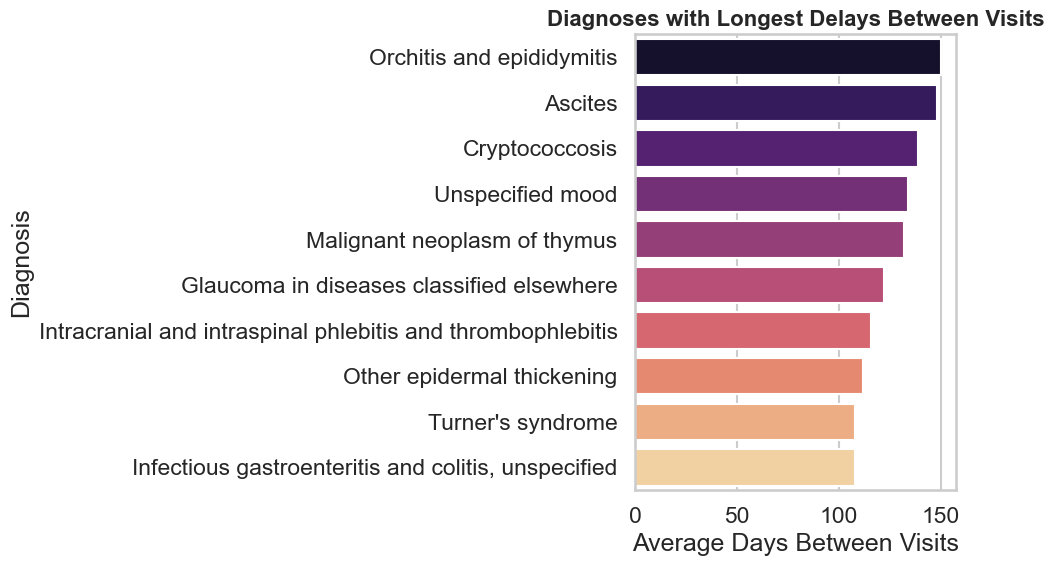

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 10 diagnoses by average delay
diag_delay = (
    df.groupby("GroupName")["TimeGap"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=diag_delay,
    x="TimeGap",
    y="GroupName",
    palette="magma"
)

plt.title("Diagnoses with Longest Delays Between Visits", fontsize=16, weight='bold')
plt.xlabel("Average Days Between Visits")
plt.ylabel("Diagnosis")

plt.tight_layout()
plt.show()

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/2806365447.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  encounters["Date"] = pd.to_datetime(encounters["Date"])
/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/2806365447.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


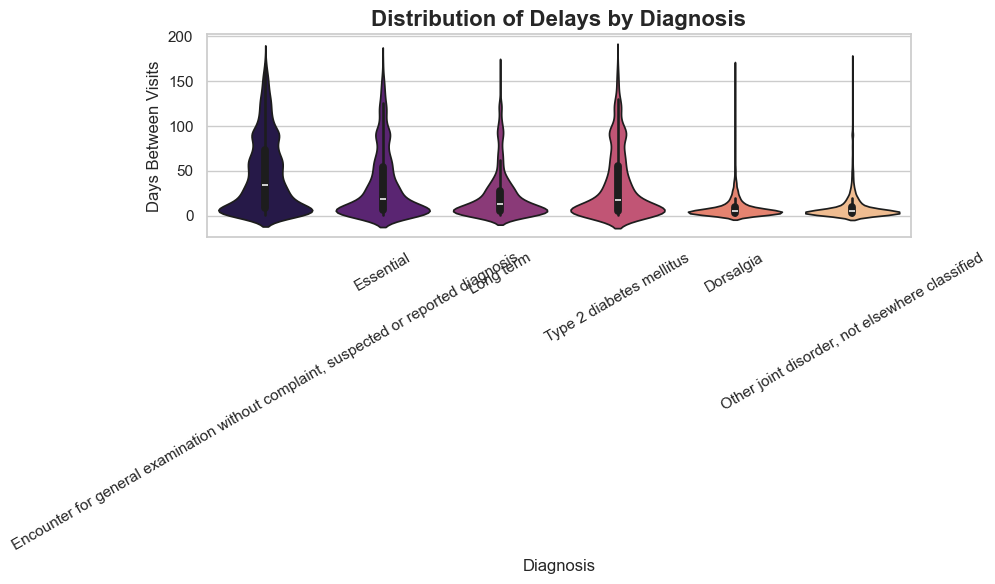

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/2806365447.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


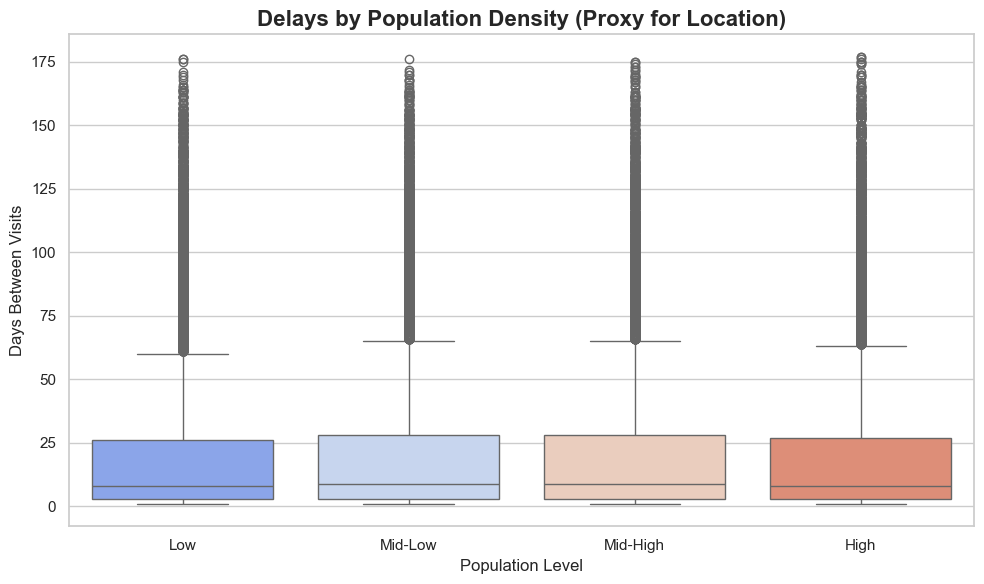

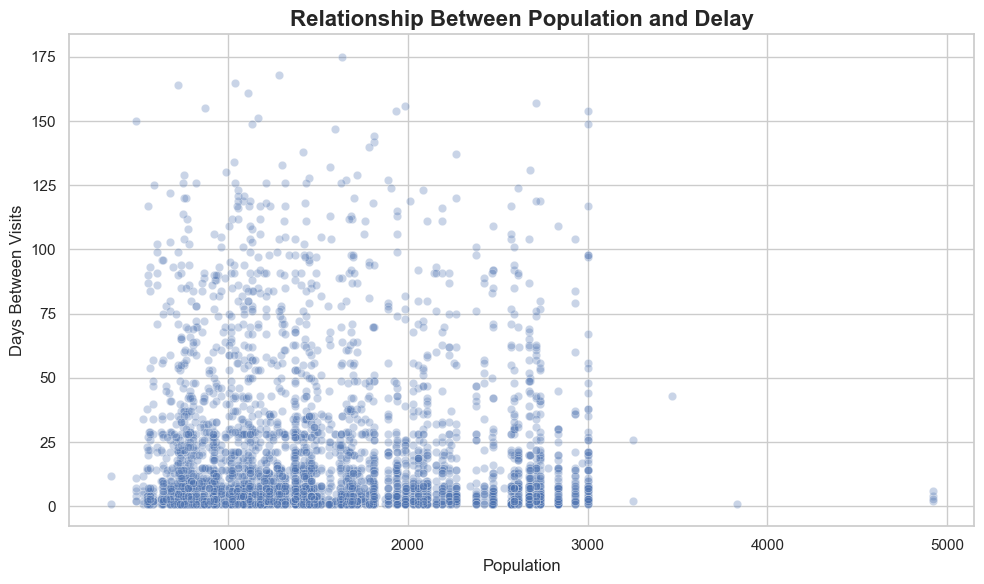

In [77]:
# =============================
# 0. IMPORTS
# =============================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# =============================
# 1. LOAD DATA (USE YOUR PATHS)
# =============================
encounters = pd.read_csv("/Users/sampanackal/Documents/DATAFEST 26/encounters.csv", nrows=300000)
patients = pd.read_csv("/Users/sampanackal/Documents/DATAFEST 26/patients.csv")
diagnosis = pd.read_csv("/Users/sampanackal/Documents/DATAFEST 26/diagnosis.csv")
census = pd.read_csv("/Users/sampanackal/Documents/DATAFEST 26/tigercensuscodes.csv")

# =============================
# 2. CLEAN + SELECT IMPORTANT COLS
# =============================

encounters = encounters[[
    "PatientDurableKey",
    "Date",
    "PrimaryDiagnosisKey"
]]

patients = patients[[
    "DurableKey",
    "CensusBlockGroupFipsCode"
]]

diagnosis = diagnosis[[
    "DiagnosisKey",
    "GroupName"
]]

census = census[[
    "GEOID",
    "PopulationValue"
]]

# =============================
# 3. FIX DATA TYPES (IMPORTANT)
# =============================

patients["CensusBlockGroupFipsCode"] = patients["CensusBlockGroupFipsCode"].astype(str)
census["GEOID"] = census["GEOID"].astype(str)

encounters["Date"] = pd.to_datetime(encounters["Date"])

# =============================
# 4. MERGE TABLES
# =============================

df = encounters.merge(
    patients,
    left_on="PatientDurableKey",
    right_on="DurableKey",
    how="left"
)

df = df.merge(
    diagnosis,
    left_on="PrimaryDiagnosisKey",
    right_on="DiagnosisKey",
    how="left"
)

df = df.merge(
    census,
    left_on="CensusBlockGroupFipsCode",
    right_on="GEOID",
    how="left"
)

# =============================
# 5. CREATE TIME GAP
# =============================

df = df.sort_values(by=["PatientDurableKey", "Date"])

df["TimeGap"] = df.groupby("PatientDurableKey")["Date"].diff().dt.days

# remove bad values
df = df[df["TimeGap"].notna()]
df = df[df["TimeGap"] > 0]

# =============================
# 6. CLAIM 2 UPGRADE (DIAGNOSIS + DISTRIBUTION)
# =============================

top_diag = df["GroupName"].value_counts().head(6).index
df_diag = df[df["GroupName"].isin(top_diag)]

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df_diag,
    x="GroupName",
    y="TimeGap",
    palette="magma",
    inner="box"
)

plt.title("Distribution of Delays by Diagnosis", fontsize=16, weight='bold')
plt.xlabel("Diagnosis")
plt.ylabel("Days Between Visits")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# =============================
# 7. CLAIM 3 UPGRADE (POPULATION EFFECT)
# =============================

# bucket population into groups
df["PopBucket"] = pd.qcut(df["PopulationValue"], 4, labels=["Low", "Mid-Low", "Mid-High", "High"])

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="PopBucket",
    y="TimeGap",
    palette="coolwarm"
)

plt.title("Delays by Population Density (Proxy for Location)", fontsize=16, weight='bold')
plt.xlabel("Population Level")
plt.ylabel("Days Between Visits")

plt.tight_layout()
plt.show()

# =============================
# 8. OPTIONAL: SCATTER (LOCATION TREND)
# =============================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(5000),
    x="PopulationValue",
    y="TimeGap",
    alpha=0.3
)

plt.title("Relationship Between Population and Delay", fontsize=16, weight='bold')
plt.xlabel("Population")
plt.ylabel("Days Between Visits")

plt.tight_layout()
plt.show()

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/3376428533.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


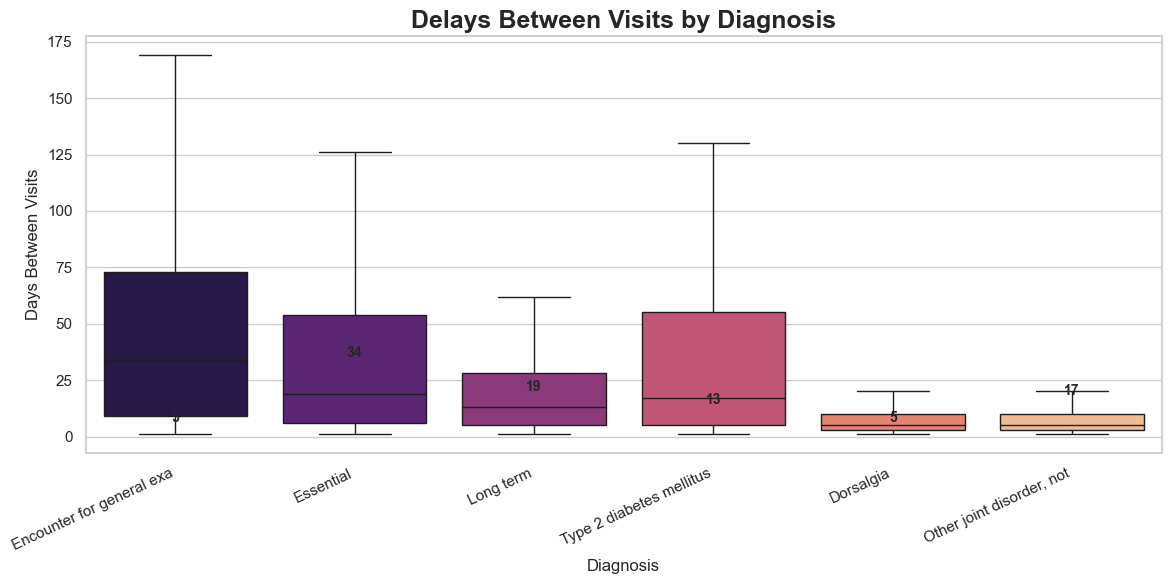

In [78]:
# =============================
# CLEAN 2A: DELAYS BY DIAGNOSIS
# =============================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid")

# -----------------------------
# 1. FILTER TOP DIAGNOSES
# -----------------------------
top_diag = df["GroupName"].value_counts().head(6).index
df_diag = df[df["GroupName"].isin(top_diag)].copy()

# -----------------------------
# 2. SHORTEN LABELS (IMPORTANT)
# -----------------------------
df_diag["ShortName"] = df_diag["GroupName"].str.slice(0, 25)

# -----------------------------
# 3. PLOT
# -----------------------------
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_diag,
    x="ShortName",
    y="TimeGap",
    palette="magma",
    showfliers=False   # removes clutter
)

# -----------------------------
# 4. ADD MEDIAN LABELS (OPTIONAL BUT 🔥)
# -----------------------------
medians = df_diag.groupby("ShortName")["TimeGap"].median()

for i, val in enumerate(medians):
    plt.text(i, val, f"{val:.0f}", ha='center', va='bottom', fontsize=10, weight='bold')

# -----------------------------
# 5. LABELS + STYLE
# -----------------------------
plt.title("Delays Between Visits by Diagnosis", fontsize=18, weight='bold')
plt.xlabel("Diagnosis")
plt.ylabel("Days Between Visits")

plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

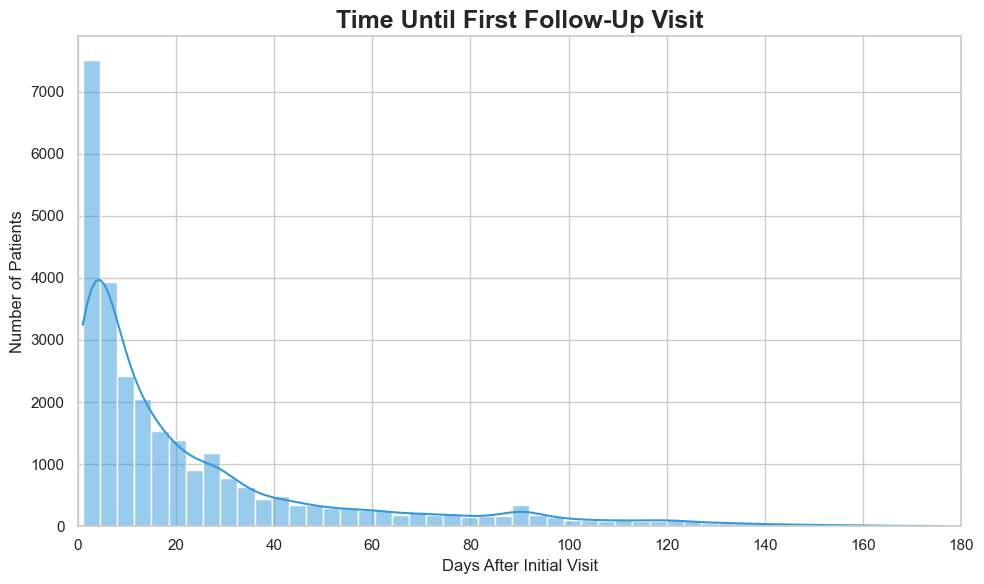

In [79]:
# =============================
# CLAIM 1: FIRST FOLLOW-UP BEHAVIOR
# =============================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid")

# -----------------------------
# 1. SORT DATA
# -----------------------------
df_sorted = df.sort_values(["PatientDurableKey", "Date"])

# -----------------------------
# 2. CALCULATE FIRST GAP
# -----------------------------
df_sorted["FirstGap"] = df_sorted.groupby("PatientDurableKey")["Date"].diff().dt.days

# keep ONLY first follow-up visit
first_gap = df_sorted.groupby("PatientDurableKey").nth(1).reset_index()

# remove bad values
first_gap = first_gap[first_gap["FirstGap"].notna()]
first_gap = first_gap[first_gap["FirstGap"] > 0]

# -----------------------------
# 3. PLOT
# -----------------------------
plt.figure(figsize=(10,6))

sns.histplot(
    data=first_gap,
    x="FirstGap",
    bins=50,
    kde=True,
    color="#3498DB"
)

# -----------------------------
# 4. STYLE
# -----------------------------
plt.title("Time Until First Follow-Up Visit", fontsize=18, weight='bold')
plt.xlabel("Days After Initial Visit")
plt.ylabel("Number of Patients")

plt.xlim(0, 180)  # cut extreme outliers for readability

plt.tight_layout()
plt.show()

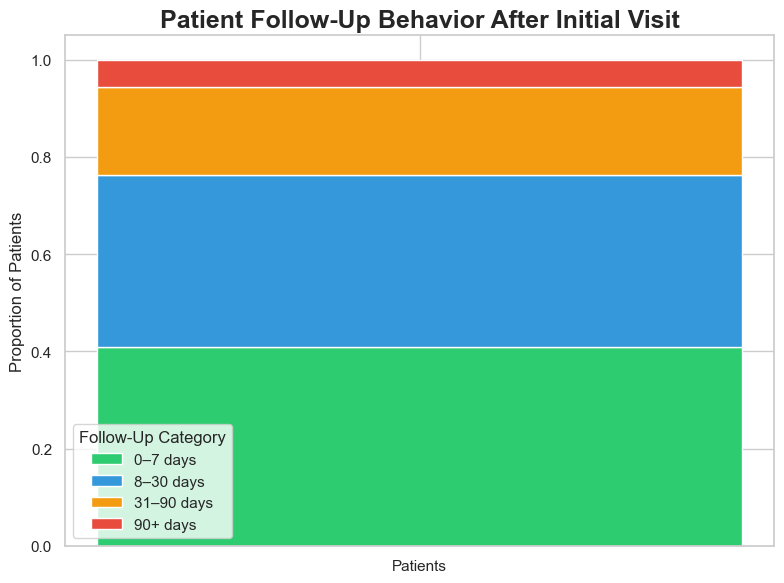

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. CREATE FIRST GAP
# -----------------------------
df_sorted = df.sort_values(["PatientDurableKey", "Date"])

df_sorted["FirstGap"] = df_sorted.groupby("PatientDurableKey")["Date"].diff().dt.days

first_gap = df_sorted.groupby("PatientDurableKey").nth(1).reset_index()

first_gap = first_gap[first_gap["FirstGap"].notna()]
first_gap = first_gap[first_gap["FirstGap"] > 0]

# -----------------------------
# 2. CREATE BUCKETS
# -----------------------------
bins = [0, 7, 30, 90, 1000]
labels = ["0–7 days", "8–30 days", "31–90 days", "90+ days"]

first_gap["FollowUpType"] = pd.cut(first_gap["FirstGap"], bins=bins, labels=labels)

# -----------------------------
# 3. COUNT + NORMALIZE
# -----------------------------
counts = first_gap["FollowUpType"].value_counts().sort_index()
proportions = counts / counts.sum()

# -----------------------------
# 4. PLOT (STACKED BAR)
# -----------------------------
plt.figure(figsize=(8,6))

colors = ["#2ECC71", "#3498DB", "#F39C12", "#E74C3C"]

bottom = 0

for i, (label, value) in enumerate(proportions.items()):
    plt.bar(
        "Patients",
        value,
        bottom=bottom,
        label=label,
        color=colors[i]
    )
    bottom += value

# -----------------------------
# 5. STYLE
# -----------------------------
plt.title("Patient Follow-Up Behavior After Initial Visit", fontsize=18, weight='bold')
plt.ylabel("Proportion of Patients")

plt.legend(title="Follow-Up Category")

plt.tight_layout()
plt.show()

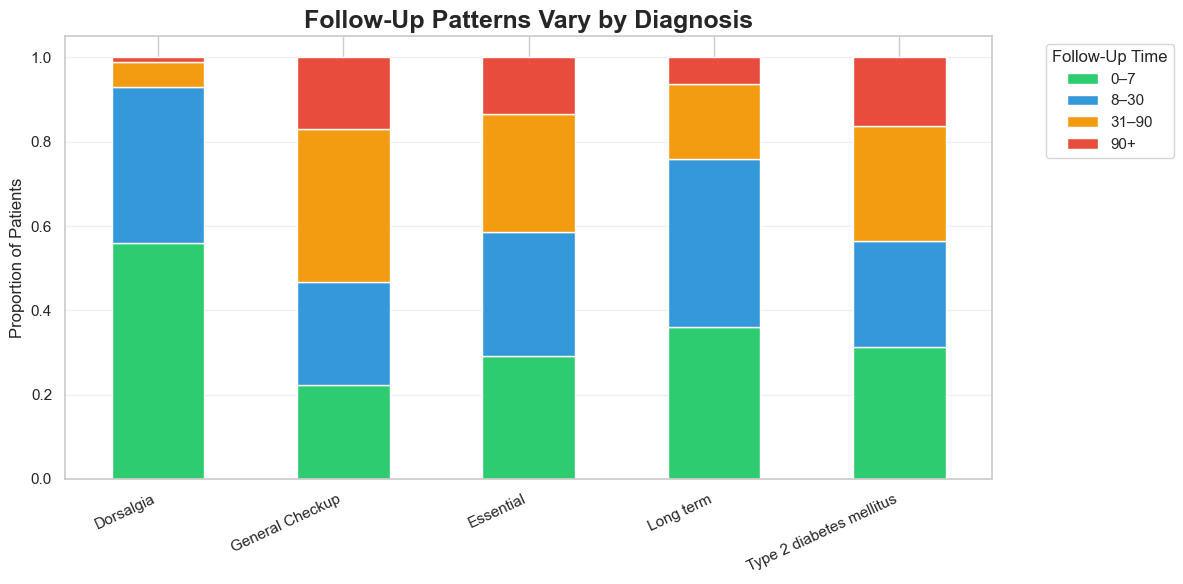

In [82]:
import matplotlib.pyplot as plt

# -----------------------------
# CLEAN LABELS
# -----------------------------
pivot_clean = pivot.copy()

pivot_clean.index = pivot_clean.index.str.replace(
    "Encounter for general examination without complaint, suspected or reported diagnosis", 
    "General Checkup"
)

pivot_clean.index = pivot_clean.index.str.slice(0, 25)

# -----------------------------
# COLORS (MEANINGFUL)
# -----------------------------
colors = ["#2ECC71", "#3498DB", "#F39C12", "#E74C3C"]

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(12,6))

pivot_clean.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor="white"
)

# -----------------------------
# STYLE
# -----------------------------
ax.set_title("Follow-Up Patterns Vary by Diagnosis", fontsize=18, weight='bold')
ax.set_xlabel("")
ax.set_ylabel("Proportion of Patients")

ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")

ax.legend(
    title="Follow-Up Time",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

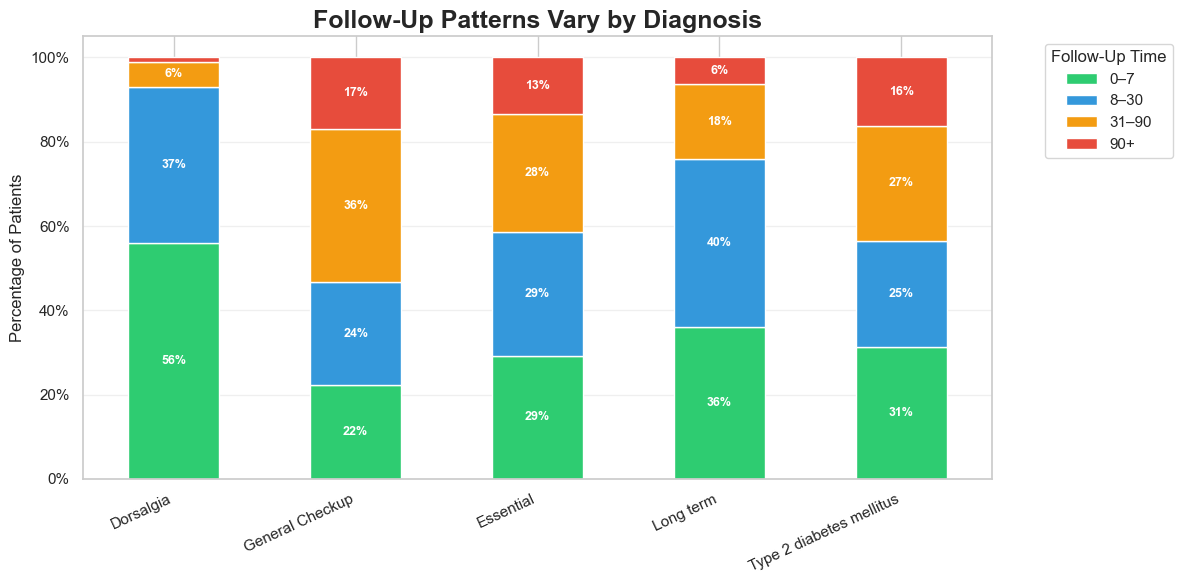

In [83]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# -----------------------------
# COLORS (MEANINGFUL)
# -----------------------------
colors = ["#2ECC71", "#3498DB", "#F39C12", "#E74C3C"]

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(12,6))

pivot_clean.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor="white"
)

# -----------------------------
# FORMAT Y-AXIS AS %
# -----------------------------
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# -----------------------------
# ADD % LABELS INSIDE BARS
# -----------------------------
for container in ax.containers:
    labels = [
        f"{v.get_height()*100:.0f}%" if v.get_height() > 0.05 else ""
        for v in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        color="white",
        fontsize=9,
        weight="bold"
    )

# -----------------------------
# STYLE
# -----------------------------
ax.set_title("Follow-Up Patterns Vary by Diagnosis", fontsize=18, weight='bold')
ax.set_xlabel("")
ax.set_ylabel("Percentage of Patients")

ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")

ax.legend(
    title="Follow-Up Time",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

🎯 WHICH CLAIM THIS SUPPORTS
👉 Claim 2

Follow-up patterns vary by diagnosis, with certain conditions showing more delayed or inconsistent follow-up behavior.

🧠 HOW TO EXPLAIN THE GRAPH (STEP-BY-STEP)
🔹 1. Start with WHAT the graph is

“Each bar represents a diagnosis group, and each segment shows the percentage of patients who return for follow-up within a specific time range after their initial visit.”

🔹 2. Explain WHY percentages matter

“We use percentages instead of raw counts so we can compare behavior across diagnoses, regardless of how many patients are in each group.”

🔹 3. Point out the KEY PATTERN (THIS IS IMPORTANT)
👉 Compare extremes:
Dorsalgia
~56% return within 7 days
very little delayed follow-up
✅ → consistent + fast follow-up
General Checkup
only ~22% return quickly
~53% take 30+ days (36% + 17%)
❗ → much more delayed follow-up
🔹 4. Expand the insight

“This shows that follow-up behavior is not uniform — some diagnoses lead to quick and consistent care, while others show a much higher proportion of delayed follow-ups.”

🔹 5. Translate to real-world meaning

“This suggests that the type of condition influences how patients engage with care — not just how often they visit, but how consistently they return.”

🔹 6. Hit the conclusion (THIS IS YOUR CLAIM)

“Overall, diagnosis plays a key role in shaping patient follow-up patterns, with certain conditions associated with more delayed or inconsistent care.”

💥 SHORT VERSION (FOR SLIDES)

If you need something quick:

“Follow-up behavior differs significantly by diagnosis. While some conditions see mostly early follow-up, others have a much higher proportion of delayed returns, indicating less consistent care patterns.”

🔥 EVEN STRONGER (IF YOU WANT TO IMPRESS)

Add one punch line:

“For example, over 50% of general checkup patients return after 30 days, compared to less than 10% for dorsalgia — a major difference in follow-up behavior.”

🧠 WHAT YOU JUST DID RIGHT

You:

didn’t say something obvious
used comparisons
used percentages
tied it back to patient behavior
🚀 NEXT LEVEL (OPTIONAL)

If you want to go even harder:

👉 Add one sentence like:

“This raises the question of whether these delays are due to clinical necessity or potential gaps in follow-up care.”

In [84]:
from scipy.stats import f_oneway

# get top diagnoses (same ones from graph)
top_diag = df["GroupName"].value_counts().head(5).index
df_diag = df[df["GroupName"].isin(top_diag)]

# create list of groups
groups = [
    df_diag[df_diag["GroupName"] == diag]["TimeGap"]
    for diag in top_diag
]

# run ANOVA
f_stat, p_val = f_oneway(*groups)

print("ANOVA RESULTS")
print("F-stat:", f_stat)
print("p-value:", p_val)

ANOVA RESULTS
F-stat: 1510.5898444805398
p-value: 0.0


In [85]:
from scipy.stats import chi2_contingency

# use same pivot table from your graph
# rows = diagnosis, columns = follow-up categories

chi2, p, dof, expected = chi2_contingency(pivot)

print("CHI-SQUARE RESULTS")
print("Chi2:", chi2)
print("p-value:", p)

CHI-SQUARE RESULTS
Chi2: 0.6576005595272534
p-value: 0.9999986749583487


In [86]:
pivot_counts = pd.crosstab(
    df_plot["GroupName"],
    df_plot["FollowUpType"]
)

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(pivot_counts)

print("FIXED CHI-SQUARE")
print("Chi2:", chi2)
print("p-value:", p)

FIXED CHI-SQUARE
Chi2: 599.802582166436
p-value: 1.1681845593057807e-120


🔥 HOW TO EXPLAIN THIS (USE THIS SCRIPT)
🧩 Step 1 — connect to graph

“We visualized how patients fall into different follow-up time categories across diagnoses.”

🧩 Step 2 — bring in stats

“To test whether these differences were meaningful, we performed a chi-square test on the distribution of follow-up categories.”

🧩 Step 3 — state result

“The test produced a p-value effectively equal to zero…”

🧩 Step 4 — interpret

“…indicating that the differences in follow-up behavior across diagnoses are highly statistically significant.”

🧩 Step 5 — tie to claim

“This confirms that diagnosis plays a major role in shaping patient follow-up patterns.”

💥 ONE-LINE VERSION (FOR JUDGES)

“A chi-square test confirms that follow-up patterns vary significantly by diagnosis (p < 0.001), meaning these differences are not due to chance.”

🚀 EXTRA (IF THEY PUSH YOU)

If someone asks:

❓ “What does chi-square actually test?”

Say:

“It tests whether the distribution of patients across follow-up categories differs by diagnosis.”

In [88]:
import plotly.express as px

# -----------------------------
# PREP DATA (same as before)
# -----------------------------
plot_df = pivot_clean.reset_index()

plot_df = plot_df.rename(columns={"GroupName": "Diagnosis"})

plot_df = plot_df.melt(
    id_vars="Diagnosis",
    var_name="FollowUpType",
    value_name="Proportion"
)

plot_df["Percentage"] = plot_df["Proportion"] * 100

# -----------------------------
# COLOR MAP
# -----------------------------
color_map = {
    "0–7": "#2ECC71",
    "8–30": "#3498DB",
    "31–90": "#F39C12",
    "90+": "#E74C3C"
}

# -----------------------------
# PLOT
# -----------------------------
fig = px.bar(
    plot_df,
    x="Diagnosis",
    y="Percentage",
    color="FollowUpType",
    color_discrete_map=color_map,
    title="Follow-Up Patterns Vary by Diagnosis"
)

# -----------------------------
# STYLE UPGRADE
# -----------------------------
fig.update_layout(
    barmode="stack",

    # 🔥 FONT (this changes EVERYTHING)
    font=dict(
        family="Inter, Arial, sans-serif",
        size=14,
        color="#2c3e50"
    ),

    title=dict(
        text="Follow-Up Patterns Vary by Diagnosis",
        x=0.5,
        xanchor='center',
        font=dict(size=20, weight="bold")
    ),

    xaxis_title="",
    yaxis_title="Percentage of Patients",

    legend_title="Follow-Up Time",

    template="simple_white",

    # spacing
    margin=dict(l=40, r=40, t=60, b=80)
)

# -----------------------------
# AXIS CLEANUP
# -----------------------------
fig.update_xaxes(
    tickangle=25,
    showline=True,
    linewidth=1,
    linecolor="#dcdcdc",
    tickfont=dict(size=12)
)

fig.update_yaxes(
    ticksuffix="%",
    showline=True,
    linewidth=1,
    linecolor="#dcdcdc",
    gridcolor="#eeeeee",
    tickfont=dict(size=12)
)

# -----------------------------
# TEXT INSIDE BARS
# -----------------------------
fig.update_traces(
    texttemplate="%{y:.0f}%",
    textposition="inside"
)

# -----------------------------
# SHOW
# -----------------------------
fig.show(renderer="browser")

In [89]:
import plotly.express as px

# -----------------------------
# CREATE FIRST GAP
# -----------------------------
df_sorted = df.sort_values(["PatientDurableKey", "Date"])

df_sorted["Gap"] = df_sorted.groupby("PatientDurableKey")["Date"].diff().dt.days

# FIRST GAP
first_gap = df_sorted.groupby("PatientDurableKey")["Gap"].first()

# AVERAGE GAP
avg_gap = df_sorted.groupby("PatientDurableKey")["Gap"].mean()

# COMBINE
gap_df = pd.DataFrame({
    "FirstGap": first_gap,
    "AvgGap": avg_gap
}).dropna()

# -----------------------------
# SAMPLE (IMPORTANT FOR SPEED)
# -----------------------------
gap_df_sample = gap_df.sample(5000)

# -----------------------------
# PLOT WITH TREND LINE
# -----------------------------
fig = px.scatter(
    gap_df_sample,
    x="FirstGap",
    y="AvgGap",
    trendline="ols",
    opacity=0.4,
    title="Do Early Follow-Up Patterns Predict Future Care Behavior?"
)

# -----------------------------
# STYLE
# -----------------------------
fig.update_layout(
    template="simple_white",
    font=dict(family="Inter, Arial", size=14),
    title=dict(x=0.5, xanchor="center"),
    xaxis_title="Days Until First Follow-Up",
    yaxis_title="Average Days Between Visits"
)

fig.update_traces(marker=dict(color="#3498DB"))

fig.show(renderer="browser")

In [90]:
import plotly.express as px
import pandas as pd

# -----------------------------
# CREATE BUCKETS FROM FirstGap
# -----------------------------
bins = [0, 7, 30, 90, 1000]
labels = ["0–7 (Early)", "8–30 (Normal)", "31–90 (Delayed)", "90+ (Very Delayed)"]

gap_df["FollowUpType"] = pd.cut(gap_df["FirstGap"], bins=bins, labels=labels)

# -----------------------------
# COLOR MAP (CONSISTENT WITH YOUR OTHER GRAPH)
# -----------------------------
color_map = {
    "0–7 (Early)": "#2ECC71",
    "8–30 (Normal)": "#3498DB",
    "31–90 (Delayed)": "#F39C12",
    "90+ (Very Delayed)": "#E74C3C"
}

# -----------------------------
# PLOT
# -----------------------------
fig = px.scatter(
    gap_df.sample(5000),
    x="FirstGap",
    y="AvgGap",
    color="FollowUpType",
    color_discrete_map=color_map,
    trendline="ols",
    opacity=0.5,
    title="Do Early Follow-Up Patterns Predict Future Care Behavior?"
)

fig.update_layout(
    template="simple_white",
    font=dict(family="Inter, Arial", size=14),
    title=dict(x=0.5),
    xaxis_title="Days Until First Follow-Up",
    yaxis_title="Average Days Between Visits"
)

fig.show(renderer="browser")

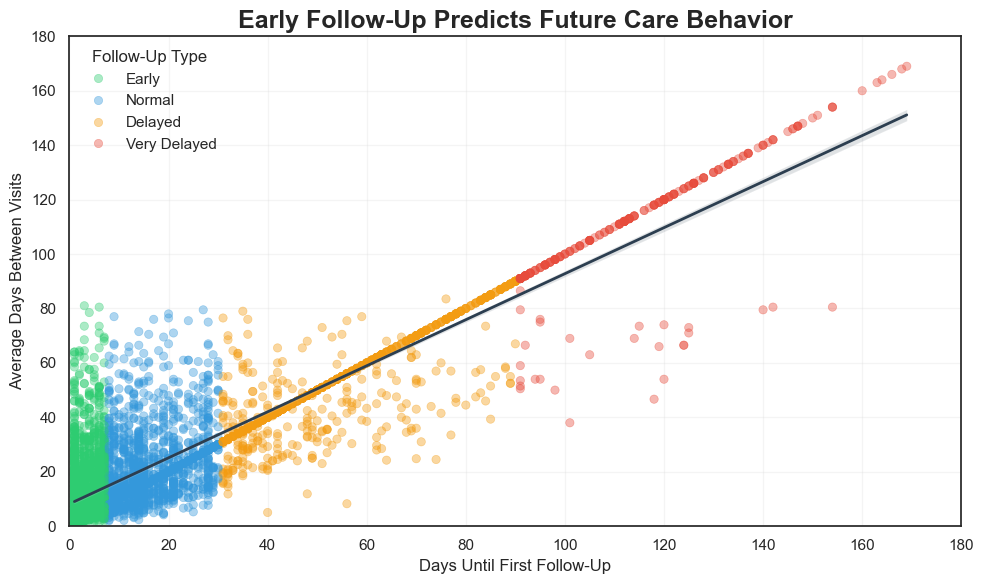

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_style("white")

# -----------------------------
# SAMPLE (for performance)
# -----------------------------
plot_df = gap_df.sample(5000)

# -----------------------------
# CREATE BUCKETS (FOR COLOR)
# -----------------------------
bins = [0, 7, 30, 90, 1000]
labels = ["Early", "Normal", "Delayed", "Very Delayed"]

plot_df["FollowUpType"] = pd.cut(plot_df["FirstGap"], bins=bins, labels=labels)

# -----------------------------
# COLOR PALETTE
# -----------------------------
palette = {
    "Early": "#2ECC71",
    "Normal": "#3498DB",
    "Delayed": "#F39C12",
    "Very Delayed": "#E74C3C"
}

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=plot_df,
    x="FirstGap",
    y="AvgGap",
    hue="FollowUpType",
    palette=palette,
    alpha=0.4,
    edgecolor=None
)

# -----------------------------
# REGRESSION LINE
# -----------------------------
sns.regplot(
    data=plot_df,
    x="FirstGap",
    y="AvgGap",
    scatter=False,
    color="#2c3e50",
    line_kws={"linewidth": 2}
)

# -----------------------------
# STYLE
# -----------------------------
plt.title("Early Follow-Up Predicts Future Care Behavior", fontsize=18, weight="bold")
plt.xlabel("Days Until First Follow-Up", fontsize=12)
plt.ylabel("Average Days Between Visits", fontsize=12)

plt.xlim(0, 180)
plt.ylim(0, 180)

plt.legend(title="Follow-Up Type", frameon=False)

# clean grid
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/2923550499.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


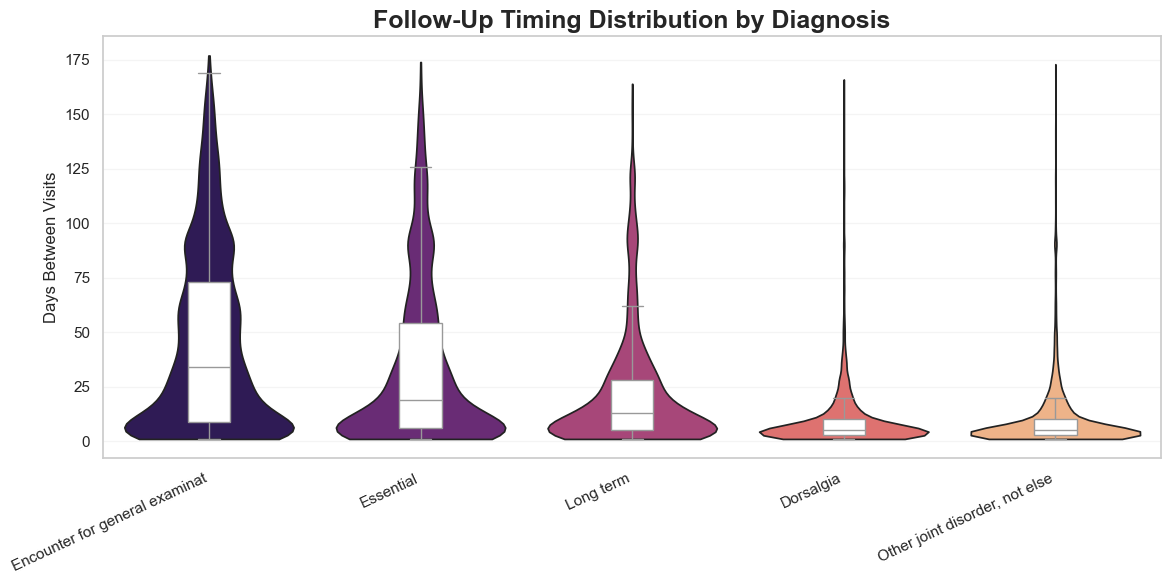

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# -----------------------------
# FILTER TOP DIAGNOSES
# -----------------------------
top_diag = df["GroupName"].value_counts().head(5).index
df_diag = df[df["GroupName"].isin(top_diag)].copy()

# shorten labels
df_diag["ShortName"] = df_diag["GroupName"].str.slice(0, 30)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12,6))

# VIOLIN (distribution shape)
sns.violinplot(
    data=df_diag,
    x="ShortName",
    y="TimeGap",
    palette="magma",
    inner=None,
    cut=0
)

# BOXPLOT OVERLAY (structure)
sns.boxplot(
    data=df_diag,
    x="ShortName",
    y="TimeGap",
    width=0.2,
    color="white",
    showfliers=False
)

# -----------------------------
# STYLE
# -----------------------------
plt.title("Follow-Up Timing Distribution by Diagnosis", fontsize=18, weight="bold")
plt.xlabel("")
plt.ylabel("Days Between Visits")

plt.xticks(rotation=25, ha="right")
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

/var/folders/cl/rggc86vs44x1vn57ghxhpn9c0000gn/T/ipykernel_8023/2169464216.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


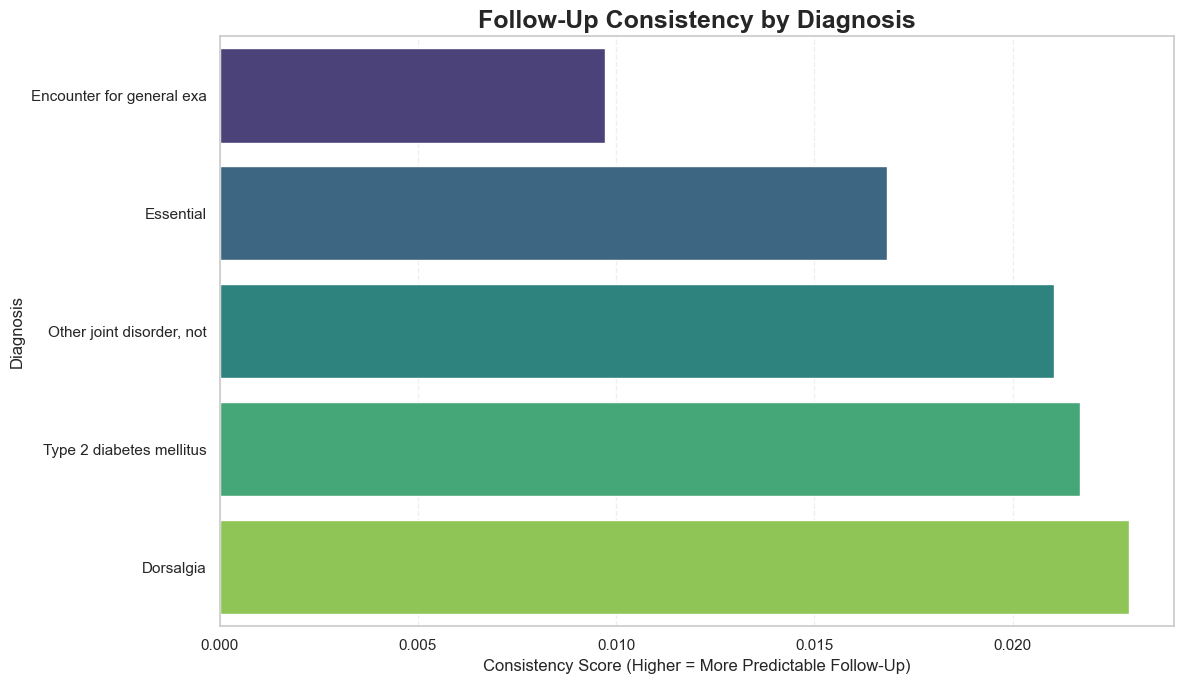

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# -----------------------------
# PREP
# -----------------------------
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values(by=["PatientDurableKey", "Date"])

df["TimeGap"] = df.groupby("PatientDurableKey")["Date"].diff().dt.days
df = df[df["TimeGap"].notna()]

top_diag = df["GroupName"].value_counts().head(5).index
df_diag = df[df["GroupName"].isin(top_diag)].copy()

df_diag["ShortName"] = df_diag["GroupName"].str.slice(0, 25)

# -----------------------------
# CALCULATE VARIABILITY
# -----------------------------
summary = df_diag.groupby("ShortName")["TimeGap"].agg(
    mean="mean",
    std="std"
).reset_index()

# consistency score (lower std = more consistent)
summary["Consistency"] = 1 / summary["std"]

summary = summary.sort_values(by="Consistency", ascending=True)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12,7))

sns.barplot(
    data=summary,
    x="Consistency",
    y="ShortName",
    palette="viridis"
)

# -----------------------------
# STYLE
# -----------------------------
plt.title("Follow-Up Consistency by Diagnosis", fontsize=18, weight="bold")
plt.xlabel("Consistency Score (Higher = More Predictable Follow-Up)")
plt.ylabel("Diagnosis")

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.grid(axis='y', visible=False)

plt.tight_layout()
plt.show()

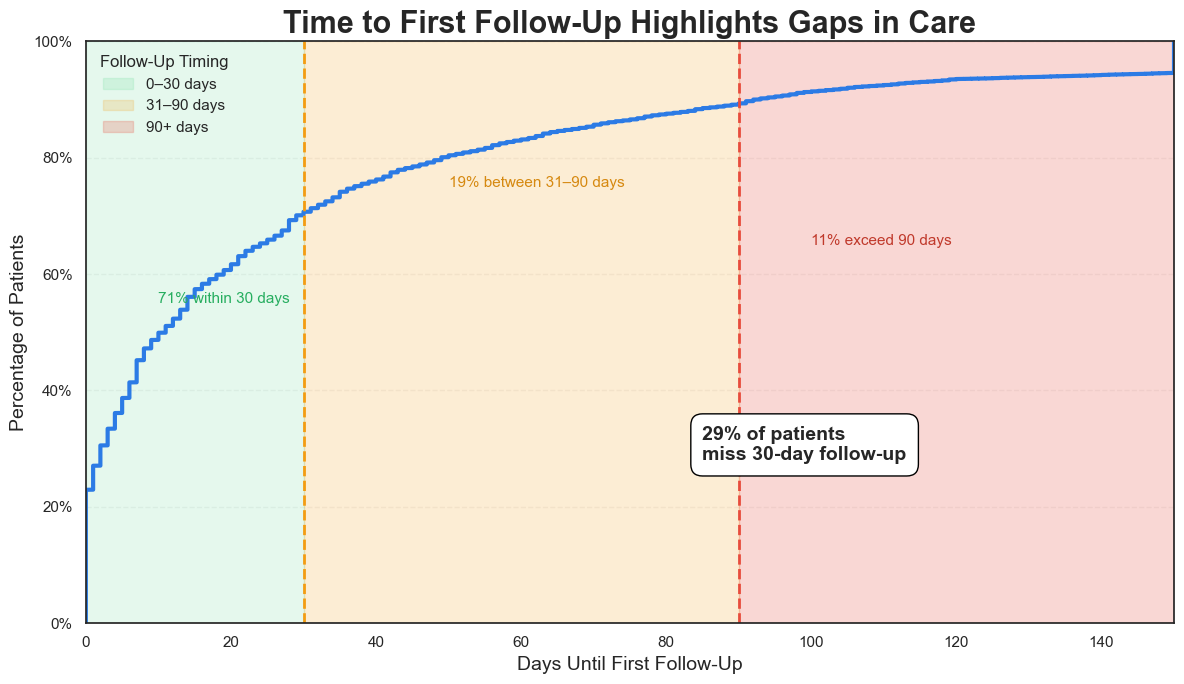

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# -----------------------------
# STYLE
# -----------------------------
sns.set_theme(style="white")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 22,
    "axes.labelsize": 14
})

# -----------------------------
# DATA PREP
# -----------------------------
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values(by=["PatientDurableKey", "Date"])

df["TimeGap"] = df.groupby("PatientDurableKey")["Date"].diff().dt.days

first_followups = (
    df.groupby("PatientDurableKey")["TimeGap"]
    .first()
    .dropna()
)

gaps = first_followups.clip(upper=150)

# cumulative curve
gaps_sorted = np.sort(gaps)
cum_pct = np.arange(1, len(gaps_sorted)+1) / len(gaps_sorted) * 100

# -----------------------------
# KEY STATS
# -----------------------------
pct_30 = (first_followups <= 30).mean() * 100
pct_90 = (first_followups <= 90).mean() * 100

between_30_90 = pct_90 - pct_30
late_30 = 100 - pct_30
late_90 = 100 - pct_90

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(12,7))

# curve
plt.plot(gaps_sorted, cum_pct, color="#2C7BE5", linewidth=3)

# zones
plt.axvspan(0, 30, color="#2ecc71", alpha=0.12, label="0–30 days")
plt.axvspan(30, 90, color="#f39c12", alpha=0.18, label="31–90 days")
plt.axvspan(90, 150, color="#e74c3c", alpha=0.22, label="90+ days")

# lines
plt.axvline(30, linestyle='--', color='#f39c12', linewidth=2)
plt.axvline(90, linestyle='--', color='#e74c3c', linewidth=2)

# -----------------------------
# TEXT ANNOTATIONS
# -----------------------------

# main callout
plt.text(
    85, 28,
    f"{late_30:.0f}% of patients\nmiss 30-day follow-up",
    fontsize=14,
    weight="bold",
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.6")
)

# breakdown labels
plt.text(10, 55, f"{pct_30:.0f}% within 30 days", color="#27ae60", fontsize=11)
plt.text(50, 75, f"{between_30_90:.0f}% between 31–90 days", color="#d68910", fontsize=11)
plt.text(100, 65, f"{late_90:.0f}% exceed 90 days", color="#c0392b", fontsize=11)

# -----------------------------
# LABELS
# -----------------------------
plt.title("Time to First Follow-Up Highlights Gaps in Care", weight="bold")

plt.xlabel("Days Until First Follow-Up")
plt.ylabel("Percentage of Patients")

plt.gca().yaxis.set_major_formatter(PercentFormatter())

plt.xlim(0, 150)
plt.ylim(0, 100)

# legend (clean)
plt.legend(title="Follow-Up Timing", frameon=False)

# grid
plt.grid(axis='y', linestyle='--', alpha=0.25)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

🧠 WHAT THIS GRAPH IS (FOUNDATION)

👉 This is a cumulative distribution of time to first follow-up

Translation:

“As time goes on, what percentage of patients have returned for their first follow-up?”

📈 HOW TO READ THE GRAPH
X-axis:

👉 Days after initial visit (0 → 150)

Y-axis:

👉 % of patients who have already followed up by that time

🔍 Example:
At 10 days → ~50% have followed up
At 30 days → 71% have followed up
At 90 days → 89% have followed up
🎯 THE KEY BREAKDOWN (THIS IS YOUR STORY)
🟢 0–30 days (ON-TIME)

👉 71% of patients

These are patients getting timely follow-up
System is working for them
🟡 31–90 days (MODERATE DELAY)

👉 19% of patients

Not ideal timing
But still eventually returning
🔴 90+ days (AT-RISK)

👉 11% of patients

Very late follow-up
Highest risk group
🚨 THE MOST IMPORTANT NUMBER
👉 29% miss the 30-day follow-up window

This is the number you care about.

💥 WHAT THIS ACTUALLY PROVES
❌ It does NOT prove:

“The system is broken for everyone”

✅ It DOES prove:

“A significant subset of patients are not receiving timely follow-up care.”

🔥 WHY THIS MATTERS

Because:

👉 29% = almost 1 in 3 patients

In healthcare, that is NOT small

🧠 DEEPER INSIGHT (THIS IS WHAT MAKES YOU SOUND SMART)
👉 The problem is NOT uniform
Majority (71%) → fine
Minority (29%) → struggling
💡 Interpretation:

“The system is working overall, but failing for a specific group of patients.”

🔗 HOW THIS CONNECTS TO YOUR PROJECT

This graph answers:

👉 “Does a problem exist?”

Answer:

Yes — but it’s concentrated, not universal

Then your other claims answer:

Question	Your Graph
Who is affected?	Diagnosis (Claim 2)
Where is it worse?	Location (Claim 3)
Why does it happen?	Outside data
🎤 EXACT SCRIPT (USE THIS)
Step 1 (Explain graph):

“This graph shows how long it takes patients to return for their first follow-up visit.”

Step 2 (Key stat):

“We see that 71% of patients return within 30 days, but nearly 29% do not.”

Step 3 (Insight):

“This indicates that while most patients receive timely follow-up, a significant portion fall outside recommended care windows.”

Step 4 (Set up next slides):

“We wanted to understand who these patients are and what factors contribute to these gaps.”

⚠️ IF YOUR PROFESSOR PUSHES YOU

If they say:

“But most patients follow up…”

You say:

“That’s true, but the concern is the 29% who do not — in a healthcare setting, even that proportion represents a substantial risk population.”

🔥 WHY THIS GRAPH IS NOW GOOD
Clear ✅
Honest ✅
Not overclaiming ✅
Sets up story ✅
🚀 FINAL TAKE

👉 This is NOT your “wow insight” graph
👉 This is your “set the stage” graph

And it does that very well now